<!--
Notebook Display Styling

This CSS block standardizes the visual presentation of the notebook when rendered in Jupyter.

Changes applied:

1. Body Text Formatting
   - Sets a consistent font size (15px)
   - Improves readability with increased line spacing (1.6)
   - Ensures uniform text appearance across markdown cells

2. Clear Heading Hierarchy
   - H1 enlarged for main section titles
   - H2 slightly smaller for major subsections
   - H3 for detailed subsections

This improves:
- Visual consistency
- Professional presentation
- Readability in exported HTML reports
-->

<style>
/* Standardize body text formatting */
.jp-RenderedHTMLCommon {
    font-size: 15px;
    line-height: 1.6;
}

/* Improve heading hierarchy clarity */
.jp-RenderedHTMLCommon h1 { font-size: 1.9em; }
.jp-RenderedHTMLCommon h2 { font-size: 1.6em; }
.jp-RenderedHTMLCommon h3 { font-size: 1.3em; }
</style>


# Credit Card Fraud Detection

## 1. 📂 Dataset Requirement

Please download the datasets from:

https://www.kaggle.com/datasets/kartik2112/fraud-detection

and place them inside:

../Data/

Required files:

- fraudTrain.csv
- fraudTest.csv

---

## 2. 📌 Project Overview
This project explores patterns in credit card transaction data to identify potential indicators of fraudulent behavior. The workflow follows an industry-standard data science pipeline, including data cleaning, feature engineering, exploratory analysis, and predictive modeling.


Special attention is paid to avoiding data leakage and ensuring feature generalizability.

### 📊 Dataset Description:

This is a simulated credit card transaction dataset containing legitimate and fraud transactions from the duration Jan 1st 2019 - Dec 31st 2020. It covers credit cards of 1000 customers doing transactions with a pool and 800 merchants. Each row represents a single credit card transaction enriched with temporal, geographic, and demographic attributes.

The dataset includes:

- Transaction details (transaction amount, transaction category, transaction timestamp)

- Temporal features (hour of transaction, day of week, weekend and nighttime indicators)

- Geographic information (customer location, merchant location, and derived transaction distance)

- Customer demographic attributes (age, gender, occupation, city population, state)

- Behavioral indicators (transaction timing patterns, distance anomalies between customer and merchant)

- Fraud label (binary indicators identifying fraudulent transactions)

The project consists of two separate datasets:

- Training dataset (fraudTrain.csv)

- Testing dataset (fraudTest.csv)

Both datasets share identical schema and variable names, enabling a clean and consistent machine learning pipeline. The testing dataset is reserved for out-of-sample evaluation only and is never used during model training or feature learning.

### 🎯 Objective
The primary objectives of this project are:

- 🧹 Clean and preprocess the transaction dataset, including handling categorical variables, transforming temporal and geographic features, and removing irrelevant or high-risk fields

- 📊 Explore and visualize transaction patterns associated with fraudulent behavior through targeted exploratory data analysis (EDA)

- 🧠 Build and compare classification models for fraud detection (e.g., logistic regression, decision trees, and ensemble methods)

- ⚖️ Address class imbalance inherent in fraud data using techniques such as class weighting or resampling methods

- 📈 Evaluate model performance using appropriate metrics, including precision, recall, F1-score, and confusion matrix, with an emphasis on fraud detection effectiveness

- 🔍 Identify key features and behavioral patterns that contribute to higher fraud risk

- 🔁 Develop a fully reusable preprocessing and modeling pipeline

All feature engineering, transformation, and model training are performed exclusively on the training dataset. The finalized pipeline is then applied unchanged to the testing dataset, ensuring a realistic evaluation setup and eliminating data leakage.

### 📂 Data Source

This dataset was obtained from the [Credit Card Transactions Fraud Detection Dataset](https://www.kaggle.com/datasets/kartik2112/fraud-detection/data).  

#### Load Files

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay,
    f1_score, recall_score, roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [5]:
import os
os.getcwd()

'/Users/thehoop/ds_projects/Portfolio/DS_projects/Credit_Card_Fraud_Detection/Notebooks'

In [6]:
fraudTest = pd.read_csv('../../../../Data/fraudTest.csv')
fraudTrain = pd.read_csv('../../../../Data/fraudTrain.csv')

In [7]:
fraudTrainC = fraudTrain.copy()
fraudTrainC.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


In [8]:
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

#### 🧪 Schema & Data Quality Checks

In [9]:
fraudTrainC.isna().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [10]:
fraudTrainC.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


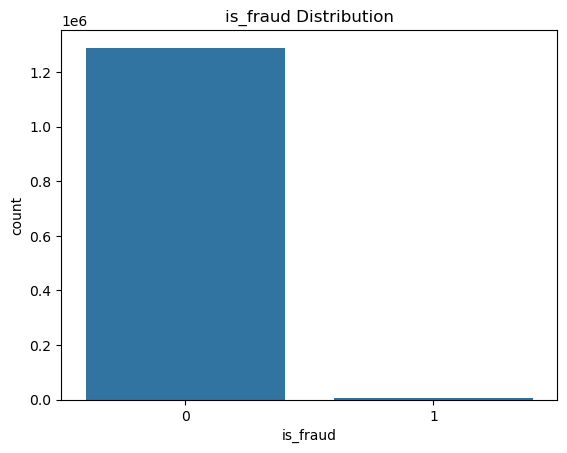

is_fraud
0    99.42%
1     0.58%
Name: proportion, dtype: object

In [11]:
# is_fraud distribution (training set only)
sns.countplot(x='is_fraud', data=fraudTrainC)
plt.title("is_fraud Distribution")
plt.show()

( fraudTrainC['is_fraud'].value_counts(normalize=True) * 100 ).map('{:.2f}%'.format)

#### Dataset Overview

In [12]:
fraudTrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [13]:
fraudTest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

## 2. 🧹 Data Processing

### Feature Selection Rationale

Certain raw fields are excluded from modeling due to high cardinality, lack of behavioral meaning, or privacy concerns.

- Identifiers (e.g., transaction ID, index columns) are removed as they do not carry predictive information.
- Raw datetime and location fields are replaced with derived behavioral features.
- Personally identifiable information (PII) is dropped after feature extraction.

These decisions help reduce noise, prevent overfitting, and improve model generalizability.


| Feature Type | Examples | Action |
|-------------|---------|--------|
| Identifiers | trans_num, index | Dropped |
| Time fields | trans_date_trans_time | Transformed |
| Demographics | dob | Derived (age), then dropped |
| Location | lat / long | To be transformed into distance |


I removed obvious identifier and privacy-sensitive fields such as names and street address from the modeling dataset, while retaining operationally useful fields like transaction ID for auditability and ZIP code for potential geographic feature engineering.

In [14]:
# Remove fields that do not contribute to prediction or may cause leakage:
# drop_cols = [
#     "Unnamed: 0", "first", "last", "street"
# ]

In [15]:
# fraudTrainC = fraudTrainC.drop(columns=drop_cols)
# fraudTrainC.head()

In [16]:
# Global Average Fraud Rate
print(f"Global Average Fraud Rate: {fraudTrainC['is_fraud'].mean():.4f}\n")

merchant_stats = fraudTrainC.groupby('merchant')['is_fraud'].agg(['count','mean'])

# Top 30 Merchants
print("Top 30 Merchants: \n", merchant_stats.sort_values('mean', ascending=False).head(20))

# Last 30 Merchants
print("\nLast 30 Merchants: \n", merchant_stats.sort_values('mean', ascending=False).tail(20))

Global Average Fraud Rate: 0.0058

Top 30 Merchants: 
                                       count      mean
merchant                                             
fraud_Kozey-Boehm                      1866  0.025723
fraud_Herman, Treutel and Dickens      1300  0.025385
fraud_Kerluke-Abshire                  1838  0.022307
fraud_Brown PLC                        1176  0.022109
fraud_Goyette Inc                      1943  0.021616
fraud_Terry-Huel                       1996  0.021543
fraud_Jast Ltd                         1953  0.021505
fraud_Schmeler, Bashirian and Price    1968  0.020833
fraud_Boyer-Reichert                   1908  0.019916
fraud_Langworth, Boehm and Gulgowski   1969  0.019807
fraud_Moore, Dibbert and Koepp         1266  0.019747
fraud_Baumbach, Feeney and Morar       1929  0.019699
fraud_Rau and Sons                     2490  0.019679
fraud_Gleason-Macejkovic               2033  0.019675
fraud_Kuhic LLC                        1985  0.019647
fraud_Kuhic, Bins and Pfeff

| Merchant | fraud rate |
|------|------------|
| High Risk | 0.02 ~ 0.025（≈ 5x global） |
| Normal | ~0.005 |
| Low Risk | 0 ~ 0.0005 |

In [17]:
category_stats = fraudTrainC.groupby('category')['is_fraud'].agg(['count','mean'])

# Top 30 Merchants
print("Categories: \n", category_stats.sort_values('mean', ascending=False))

# Last 30 Merchants
print("\nLast 30 Categories: \n", category_stats.sort_values('mean', ascending=False))

Categories: 
                  count      mean
category                        
shopping_net     97543  0.017561
misc_net         63287  0.014458
grocery_pos     123638  0.014098
shopping_pos    116672  0.007225
gas_transport   131659  0.004694
misc_pos         79655  0.003139
grocery_net      45452  0.002948
travel           40507  0.002864
entertainment    94014  0.002478
personal_care    90758  0.002424
kids_pets       113035  0.002114
food_dining      91461  0.001651
home            123115  0.001608
health_fitness   85879  0.001549

Last 30 Categories: 
                  count      mean
category                        
shopping_net     97543  0.017561
misc_net         63287  0.014458
grocery_pos     123638  0.014098
shopping_pos    116672  0.007225
gas_transport   131659  0.004694
misc_pos         79655  0.003139
grocery_net      45452  0.002948
travel           40507  0.002864
entertainment    94014  0.002478
personal_care    90758  0.002424
kids_pets       113035  0.002114
food_d

| Category | fraud rate |
|------|------------|
| High Risk | ≈ 3x global |
| Low Risk | ≈ 0.3x global |

## 3. 🛠️ Feature Engineering

### 3.1 🚀 Transaction Speed

### Definition

Transaction speed measures how quickly a credit card is used across geographic locations by combining spatial distance with the elapsed time between consecutive transactions.

This feature captures spatial deviations from a cardholder’s typical purchasing region, which may indicate unauthorized usage.

$$
\text{Transaction Speed (km/h)} = 
\frac{\text{Transaction Distance (km)}}{\text{Time Gap (hours)}}
$$

Where:

- **Transaction Distance** is calculated using the **Haversine formula**, which estimates the great-circle distance between customer and merchant locations on the Earth's surface.
- **Time Gap** represents the time elapsed since the previous transaction for the same credit card.

---

### Why Use the Haversine Formula?

Latitude and longitude coordinates lie on a spherical surface rather than a flat plane. The Haversine formula accounts for the Earth's curvature, providing a more accurate estimate of real-world travel distance compared to simple Euclidean calculations.

Transforming raw geographic coordinates into distance helps capture **spatial anomalies**, while combining distance with time enables the detection of **physically implausible travel patterns** — a strong indicator of potential fraudulent activity.

---

### Is This a Problem?

It depends on the model type:

- For Linear Models (e.g., Logistic Regression):
❌ This can be problematic due to unstable coefficients and sensitivity to correlated features.
- For Tree-Based Models (e.g., XGBoost, Random Forest, CatBoost):
✅ This is generally not an issue

---

### Tree-based models:

Do not rely on linear relationships
Do not require feature independence
Automatically select the most informative feature splits

As a result, the model can internally choose between:

Distance-based signals
Time-based signals
Speed-based signals

depending on which provides the strongest predictive power.

---

### Objective of This Feature

The goal of constructing the transaction speed feature is to identify abnormal behavioral patterns. Transactions occurring at unrealistically high speeds may suggest compromised cards, account takeover, or unauthorized usage.

After deriving this feature, the original coordinate variables are removed to reduce redundancy and prevent multicollinearity in the modeling stage.

**Example:**
Ordered a cup of coffee at a Starbucks in NYC vs Shopping in Toyko 3 hours later ---> fraud signal

In [18]:
def haversine_vectorized(lat1, lon1, lat2, lon2, radius_km=6371.0):
    """
    Vectorized Haversine distance
    Accepts scalars/NumPy arrays/pandas Series and return distances in km
    """

    # Convert inputs to numpy arrays (handles pandas Series too)
    lat1 = np.array(lat1, dtype="float64")
    lon1 = np.array(lon1, dtype="float64")
    lat2 = np.array(lat2, dtype="float64")
    lon2 = np.array(lon2, dtype="float64")

    # Convert degrees -> radians (trig functions expect radians)
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    # Compute deltas (difference between points)
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Haversine "a" term (half-versed-sine based)
    a = (
        np.sin(dlat/2)**2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    )

    # Central angle c (theta in radians)
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))

    # Arc length on sphere = radius * angle
    return radius_km * c

def add_distance_feature(df, lat_col="lat", lon_col="long",
                        merch_lat_col="merch_lat", merch_lon_col="merch_long",
                        out_col="txn_distance_km"):
    """
    Adds a transaction distance feature to df and returns df.
    Designed to be reusable on both train and test.
    """

    # Compute distance using the vectorized haversine function
    df[out_col] = haversine_vectorized(
        df[lat_col],
        df[lon_col],
        df[merch_lat_col],
        df[merch_lon_col]
    )

    return df

In [19]:
def add_time_features(df, id_col='cc_num', dt_col="trans_date_trans_time"):

    df = df.copy()
    
    # Convert to datetime
    df[dt_col] = pd.to_datetime(df[dt_col])
    
    # Sort by card num and transaction time
    df = df.sort_values([id_col, dt_col])

    # Use sorted datetime column
    dt = df[dt_col]

    df["year"] = dt.dt.year
    df["hour"] = dt.dt.hour
    df['dayofweek'] = dt.dt.dayofweek # Mon=0
    df['month'] = dt.dt.month
    
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_night'] = ((df['hour'] <= 5) | (df['hour'] >= 22)).astype(int)
    
    # Cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)

    return df

In [20]:
def add_time_gap_and_speed(
    df,
    id_col='cc_num',
    time_col='unix_time',
    dist_col='txn_distance_km',
    speed_clip_upper=None
):

    df = df.copy()
    df = df.sort_values([id_col, time_col])
    
    df['time_gap_sec'] = df.groupby(id_col)[time_col].diff()
    df['time_gap_hr'] = df["time_gap_sec"] / 3600
    
    # avoid divide-by-zero / extreme vals
    # Series.clip(lower=minimum, upper=maximum)
    gap_hr = df['time_gap_hr'].clip(lower=1/3600) # at least 1 sec
    df['txn_speed_kmh'] = df[dist_col] / gap_hr

    if speed_clip_upper is None:
        speed_clip_upper = df['txn_speed_kmh'].quantile(0.99)
    
    df['txn_speed_kmh_clip'] = df['txn_speed_kmh'].clip(upper=speed_clip_upper)
    
    # # optional: log transforms
    # df['time_gap_log'] = np.log1p(df['time_gap_sec'].clip(lower=0)) # log val cannot be negative
    # # df['speed_log'] = np.log1p(df['txn_speed_kmh'].clip(lower=0))
    # df['city_pop_log'] = np.log1p(df['city_pop']).clip(lower=0)

    return df, speed_clip_upper

def add_log_features(
    df,
    amt_col='amt',
    time_gap_col='time_gap_sec',
    speed_kmh_col='txn_speed_kmh_clip',
    city_pop_col='city_pop'
):
    df = df.copy()

    # log transform
    df['time_gap_log'] = np.log1p(df[time_gap_col].clip(lower=0))
    df['txn_speed_kmh_clip_log'] = np.log1p(df[speed_kmh_col].clip(lower=0))
    df['amt_log'] = np.log1p(df[amt_col].clip(lower=0))
    df['city_pop_log'] = np.log1p(df[city_pop_col].clip(lower=0))

    return df

In [21]:
fraudTrainC = fraudTrain.copy()

fraudTrainC = add_distance_feature(fraudTrainC)
fraudTrainC = add_time_features(fraudTrainC)
fraudTrainC, speed_clip_upper = add_time_gap_and_speed(fraudTrainC)
fraudTrainC = add_log_features(fraudTrainC)

In [22]:
fraudTrainC['txn_speed_kmh'].quantile([.99, .995, .999, 1.0])

0.990      1445.219986
0.995      2887.674899
0.999     14317.256709
1.000    457542.341306
Name: txn_speed_kmh, dtype: float64

In [23]:
fraudTrainC['txn_speed_kmh_clip'].quantile([.99, .995, .999, 1.0])

0.990    1445.213477
0.995    1445.219986
0.999    1445.219986
1.000    1445.219986
Name: txn_speed_kmh_clip, dtype: float64

In [24]:
fraudTrainC["txn_speed_kmh"].max(), fraudTrainC["txn_speed_kmh_clip"].max()

(457542.34130633867, 1445.2199858986924)

In [25]:
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 1017 to 1296427
Data columns (total 42 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   Unnamed: 0              1296675 non-null  int64         
 1   trans_date_trans_time   1296675 non-null  datetime64[ns]
 2   cc_num                  1296675 non-null  int64         
 3   merchant                1296675 non-null  object        
 4   category                1296675 non-null  object        
 5   amt                     1296675 non-null  float64       
 6   first                   1296675 non-null  object        
 7   last                    1296675 non-null  object        
 8   gender                  1296675 non-null  object        
 9   street                  1296675 non-null  object        
 10  city                    1296675 non-null  object        
 11  state                   1296675 non-null  object        
 12  zip             

### 3.2 Demographic Features
- Age calculation

In [26]:
# ----------------------------------
# Demographic Feature
# ----------------------------------

def demo_feature(
    df,
    dob_col='dob',
    date_time_col='trans_date_trans_time'
):

    df = df.copy()
    
    # Convert to datetime - 'dob'
    df['dob'] = pd.to_datetime(df[dob_col])
    df['trans_date_trans_time'] = pd.to_datetime(df[date_time_col])

    # Extract time-based features - 'dob'
    # Calculate age difference between the transaction timestamp and the customer's dob
    # If the transaction occurred before the person’s birthday in that year, subtract one from the age; otherwise (after dob), the age remains unchanged.
    # (trans_month) < (birth_month) or (trans_month == birth_month) & (trans_day < birth_day)
    t = df['trans_date_trans_time']
    b = df['dob']

    before_bday = (t.dt.month < b.dt.month) | ((t.dt.month == b.dt.month) & (t.dt.day < b.dt.day))

    df['age'] = (t.dt.year - b.dt.year) - before_bday.astype(int)

    return df

In [27]:
fraudTrainC = demo_feature(fraudTrainC)

In [28]:
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 1017 to 1296427
Data columns (total 43 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   Unnamed: 0              1296675 non-null  int64         
 1   trans_date_trans_time   1296675 non-null  datetime64[ns]
 2   cc_num                  1296675 non-null  int64         
 3   merchant                1296675 non-null  object        
 4   category                1296675 non-null  object        
 5   amt                     1296675 non-null  float64       
 6   first                   1296675 non-null  object        
 7   last                    1296675 non-null  object        
 8   gender                  1296675 non-null  object        
 9   street                  1296675 non-null  object        
 10  city                    1296675 non-null  object        
 11  state                   1296675 non-null  object        
 12  zip             

In [29]:
# =========================
# DROP USELESS COLUMNS
# =========================

drop_cols = [
    # time
    # 'trans_date_trans_time',
    'unix_time',

    # ID
    'trans_num',
    # 'cc_num',

    # raw replaced
    'time_gap_sec',
    'time_gap_hr',
    'txn_speed_kmh',

    # cyclical replaced
    'hour',
    'dayofweek',

    # raw features
    # 'amt', keep
    'city_pop',
    'dob',

    # geo
    'lat',
    'long',
    'merch_lat',
    'merch_long',

    # noise
    'Unnamed: 0',
    'first',
    'last',
    'street'
]

fraudTrainC = fraudTrainC.drop(columns=drop_cols)

In [31]:
import os

data_path = os.path.join("..", "..", "..", "..", "Data", "fraudTrain_cleaned.csv")

fraudTrainC.to_csv(data_path, index=False)

In [32]:
fraudTrainC.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 1017 to 1296427
Data columns (total 26 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   trans_date_trans_time   1296675 non-null  datetime64[ns]
 1   cc_num                  1296675 non-null  int64         
 2   merchant                1296675 non-null  object        
 3   category                1296675 non-null  object        
 4   amt                     1296675 non-null  float64       
 5   gender                  1296675 non-null  object        
 6   city                    1296675 non-null  object        
 7   state                   1296675 non-null  object        
 8   zip                     1296675 non-null  int64         
 9   job                     1296675 non-null  object        
 10  is_fraud                1296675 non-null  int64         
 11  txn_distance_km         1296675 non-null  float64       
 12  year            